# **Pregunta 12 Parcial 1**
### - Paola Figueroa
### - 2/Marzo/2026

**Ejercicio Python 1: Construcción de un portafolio eficiente con simulación**
- Evaluar la capacidad para aplicar simulaciones Monte Carlo en la construcción y análisis de portafolios con distintos niveles de riesgo y rendimiento.

- Descarga precios históricos de tres activos financieros distintos El periodo de análisis debe cubrir al menos 3 años.

- Calcula los rendimientos diarios y estima sus medias y matriz de covarianzas.

- Simula al menos 10,000 portafolios conformados por los tres activos, con pesos aleatorios que sumen 1.

- Para cada portafolio, calcula:

    - Rendimiento esperado.

    - Riesgo (desviación estándar).

    - Ratio de Sharpe (considera una tasa libre de riesgo de 4% anual).

    - Grafica el diagrama riesgo–rendimiento con todos los portafolios. En la misma figura:

    - Identifica el portafolio de menor riesgo.

    - Identifica el portafolio de mayor rendimiento.

    - Identifica el portafolio con mayor Sharpe.

    - Redacta un breve análisis, usando markdown en tu notebook, explicando qué portafolio recomendarías y por qué.

In [1]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
tickers = ["JPM", "MSFT", "TSM"]
data = yf.download(tickers, start="2023-01-01", progress=False)['Close']
data.head()

Ticker,JPM,MSFT,TSM
Date,,,
2023-01-03,124.928703,233.452805,70.652878
2023-01-04,126.093697,223.240829,72.838417
2023-01-05,126.065720,216.624451,72.275345
2023-01-06,128.478058,219.177460,74.508575
2023-01-09,127.947166,221.311462,76.646385


In [3]:
# Rendimientos
rets=data.pct_change().dropna()
print("Rendimientos de las empresas: ", rets)

# Medias
mean=rets.mean()
print("Media de los rendimientos: ", mean)

# matriz de covarianza
cov=rets.cov()
print("Matriz de covarianza: ", cov)

Rendimientos de las empresas:  Ticker           JPM      MSFT       TSM
Date                                    
2023-01-04  0.009325 -0.043743  0.030933
2023-01-05 -0.000222 -0.029638 -0.007730
2023-01-06  0.019136  0.011785  0.030899
2023-01-09 -0.004132  0.009736  0.028692
2023-01-10  0.008954  0.007617  0.011954
...              ...       ...       ...
2026-02-24 -0.001243  0.011782  0.042455
2026-02-25  0.020182  0.029820  0.005133
2026-02-26  0.009331  0.002796 -0.028164
2026-02-27 -0.019044 -0.022354 -0.005918
2026-03-02 -0.009124  0.014793 -0.014603

[791 rows x 3 columns]
Media de los rendimientos:  Ticker
JPM     0.001206
MSFT    0.000792
TSM     0.002373
dtype: float64
Matriz de covarianza:  Ticker       JPM      MSFT       TSM
Ticker                              
JPM     0.000217  0.000054  0.000090
MSFT    0.000054  0.000232  0.000156
TSM     0.000090  0.000156  0.000563


In [4]:
#Asignamos parámetros base
num_portafolios = 10000
weights = np.array([0.40, 0.30, 0.30])
rf_anual = 0.04
rf_diario = rf_anual / 252


resultados = []

# 2. Simulación de Portafolios y Monte Carlo
np.random.seed(42)
for i in range(num_portafolios):
    # Generar pesos: el primero es el sugerido, los demás aleatorios
    if i == 0:
        w = weights
    else:
        w = np.random.dirichlet(np.ones(len(tickers)), size=1)[0]
    
    # Simulación de rendimientos para esta combinación de pesos
    sim_returns_activos = np.random.multivariate_normal(mean, cov, num_portafolios)
    port_sim_returns = sim_returns_activos @ w
    
    # Cálculos estadísticos
    rend_prom = np.mean(port_sim_returns)
    desv_std = np.std(port_sim_returns)
    var_95 = np.percentile(port_sim_returns, 5) # Percentil 5 para VaR 95%
    sharpe_ratio = (rend_prom - rf_diario) / desv_std
    
    resultados.append({
        'Pesos': w,
        'Rendimiento_Medio': rend_prom,
        'Desv_Std': desv_std,
        'VaR_95': var_95,
        'Ratio de Sharpe': sharpe_ratio
    })

df = pd.DataFrame(resultados)

In [5]:
# Parámetros
num_portafolios = 10000
rf_anual = 0.04
resultados = []

np.random.seed(42)

for i in range(num_portafolios):
    w = np.random.dirichlet(np.ones(len(tickers)))
    rend_diario = np.dot(w, mean)
    riesgo_diario = np.sqrt(np.dot(w.T, np.dot(cov, w)))
    rend_anual = rend_diario * 252
    riesgo_anual = riesgo_diario * np.sqrt(252)
    sharpe = (rend_anual - rf_anual) / riesgo_anual
    resultados.append([w, rend_anual, riesgo_anual, sharpe])

df = pd.DataFrame(resultados, columns=["Pesos", "Rendimiento", "Riesgo", "Sharpe"])


In [6]:
df

,Pesos,Rendimiento,Riesgo,Sharpe
0,"[0.09784296501149996, 0.6276139633959614, 0.27...",0.319184,0.225201,1.239709
1,"[0.729092004503085, 0.13546540941426943, 0.135...",0.329605,0.203321,1.424371
2,"[0.0200119501874526, 0.6726183177105184, 0.307...",0.324142,0.238352,1.192111
3,"[0.25890493093112465, 0.004373639091215078, 0....",0.520022,0.299420,1.603171
4,"[0.8026024923499441, 0.10723696528112109, 0.09...",0.319237,0.208368,1.340115
...,...,...,...,...
9995,"[0.46295115847981305, 0.49008056158495206, 0.0...",0.266626,0.187260,1.210222
9996,"[0.4023116209871141, 0.19378386743797035, 0.40...",0.402441,0.223272,1.623312
9997,"[0.8316256399152308, 0.0954595636054364, 0.072...",0.315395,0.211054,1.304856
9998,"[0.06628514856957726, 0.6426898491615937, 0.29...",0.322457,0.230606,1.224849


In [7]:
# Portafolios claves

# Portafolio de menor riesgo
min_riesgo = df.loc[df["Riesgo"].idxmin()]
# Portafolio de mayor rendimiento
max_rend = df.loc[df["Rendimiento"].idxmax()]
# Portafolio de mayor Sharpe
max_sharpe = df.loc[df["Sharpe"].idxmax()]

min_riesgo, max_rend, max_sharpe

(Pesos          [0.512102838147254, 0.44736029799134813, 0.040...
 Rendimiento                                             0.269189
 Riesgo                                                  0.186801
 Sharpe                                                  1.226915
 Name: 4556, dtype: object,
 Pesos          [0.006615507227936485, 0.00253866672786374, 0....
 Rendimiento                                             0.594915
 Riesgo                                                  0.374042
 Sharpe                                                  1.483562
 Name: 5227, dtype: object,
 Pesos          [0.5092777392327842, 0.001532254686179143, 0.4...
 Rendimiento                                             0.447555
 Riesgo                                                   0.24395
 Sharpe                                                  1.670649
 Name: 5830, dtype: object)

/var/folders/29/_3vm7gk56clb5h32hztvyvzm0000gn/T/ipykernel_15281/4142132567.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df["Riesgo"], df["Rendimiento"], cmap="viridis", alpha=0.6)


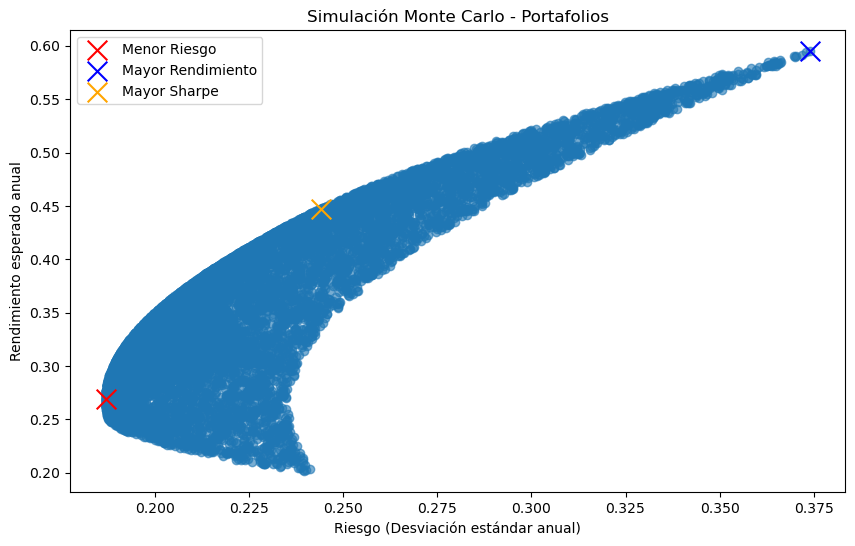

In [8]:
# Gráfica (riesgo- rendimiento)
# En una de mis clases estudiamos la Bala de Markowitz con la frontera eficiente, por lo que usaré esa gráfica para explicar el comportamiento de los portafolios

plt.figure(figsize=(10,6))
plt.scatter(df["Riesgo"], df["Rendimiento"], cmap="viridis", alpha=0.6)

plt.scatter(min_riesgo["Riesgo"], min_riesgo["Rendimiento"], c='red', marker='x', s=200, label="Menor Riesgo")
plt.scatter(max_rend["Riesgo"], max_rend["Rendimiento"],c='blue', marker='x', s=200, label="Mayor Rendimiento")
plt.scatter(max_sharpe["Riesgo"], max_sharpe["Rendimiento"],c='orange', marker='x', s=200, label="Mayor Sharpe")

plt.xlabel("Riesgo (Desviación estándar anual)")
plt.ylabel("Rendimiento esperado anual")
plt.title("Simulación Monte Carlo - Portafolios")
plt.legend()
plt.show()


## **¿Qué portafolio recomendaría?**
El portafolio de menor riesgo presenta la menor volatilidad, pero también un rendimiento esperado más moderado, mientras que el portafolio de mayor rendimiento ofrece el retorno esperado más alto, aunque acompañado de un nivel elevado de riesgo. Por el otro lado, de una manera más balanceada, el portafolio con mayor ratio de Sharpe representa la mejor relación riesgo–rendimiento, ya que maximiza el exceso de rendimiento por unidad de riesgo asumido.
Personalmente eligiría elportafolio con mayor Sharpe, ya que optimiza la eficiencia del capital invertido al ofrecer la mejor compensación por riesgo, consistente con la teoría moderna. No obstante no hay un "mejor" portafolio que otro porque depende del objetivo, ya que "Mejor" no es absoluto: si la prioridad es protegerse de pérdidas, el de menor riesgo. Si buscamos el mayor rendimiento ajustado al riesgo, gana el de máximo Sharpe. La calidad de un portafolio siempre se mide en función del perfil del inversionista y del horizonte de tiempo.